## Lecture & inspection initiale

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import string
import seaborn as sns
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
from wordcloud import WordCloud
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print("✔ Librairies chargées")

✔ Librairies chargées


## Chargement du dataset brut

In [2]:
file_path = "raw_tweets.csv"
df = pd.read_csv(file_path, encoding="utf-8")

print("✔ Dataset brut chargé")

✔ Dataset brut chargé


## INFORMATIONS GÉNÉRALES DU DATASET

In [3]:
print(f"Nombre de tweets: {len(df):,}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"\nPériode couverte:")
print(f"  • Du: {df['created_at'].min()}")
print(f"  • Au: {df['created_at'].max()}")

print("\n📋 Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Nombre de tweets: 6,375
Nombre de colonnes: 22

Période couverte:
  • Du: 2020-12-28 08:26:23 +01:00
  • Au: 2025-06-17 12:03:57 +02:00

📋 Colonnes disponibles:
   1. id
   2. created_at
   3. full_text
   4. media
   5. screen_name
   6. name
   7. profile_image_url
   8. user_id
   9. in_reply_to
  10. retweeted_status
  11. quoted_status
  12. media_tags
  13. favorite_count
  14. retweet_count
  15. bookmark_count
  16. quote_count
  17. reply_count
  18. views_count
  19. favorited
  20. retweeted
  21. bookmarked
  22. url


## Détection des doublons

In [4]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")
doubl = df[df.duplicated()].sum()
print(doubl)

Nombre de doublons : 0
id                     0
created_at             0
full_text              0
media                  0
screen_name            0
name                   0
profile_image_url      0
user_id                0
in_reply_to          0.0
retweeted_status     0.0
quoted_status        0.0
media_tags             0
favorite_count         0
retweet_count          0
bookmark_count         0
quote_count            0
reply_count            0
views_count          0.0
favorited              0
retweeted              0
bookmarked             0
url                    0
dtype: object


## Analyse de complétude

,Colonne,Valeurs_Non_Null,Valeurs_Null,Complétude_%
0,id,6375,0,100.0
1,created_at,6375,0,100.0
20,bookmarked,6375,0,100.0
19,retweeted,6375,0,100.0
18,favorited,6375,0,100.0
16,reply_count,6375,0,100.0
15,quote_count,6375,0,100.0
14,bookmark_count,6375,0,100.0
13,retweet_count,6375,0,100.0
12,favorite_count,6375,0,100.0


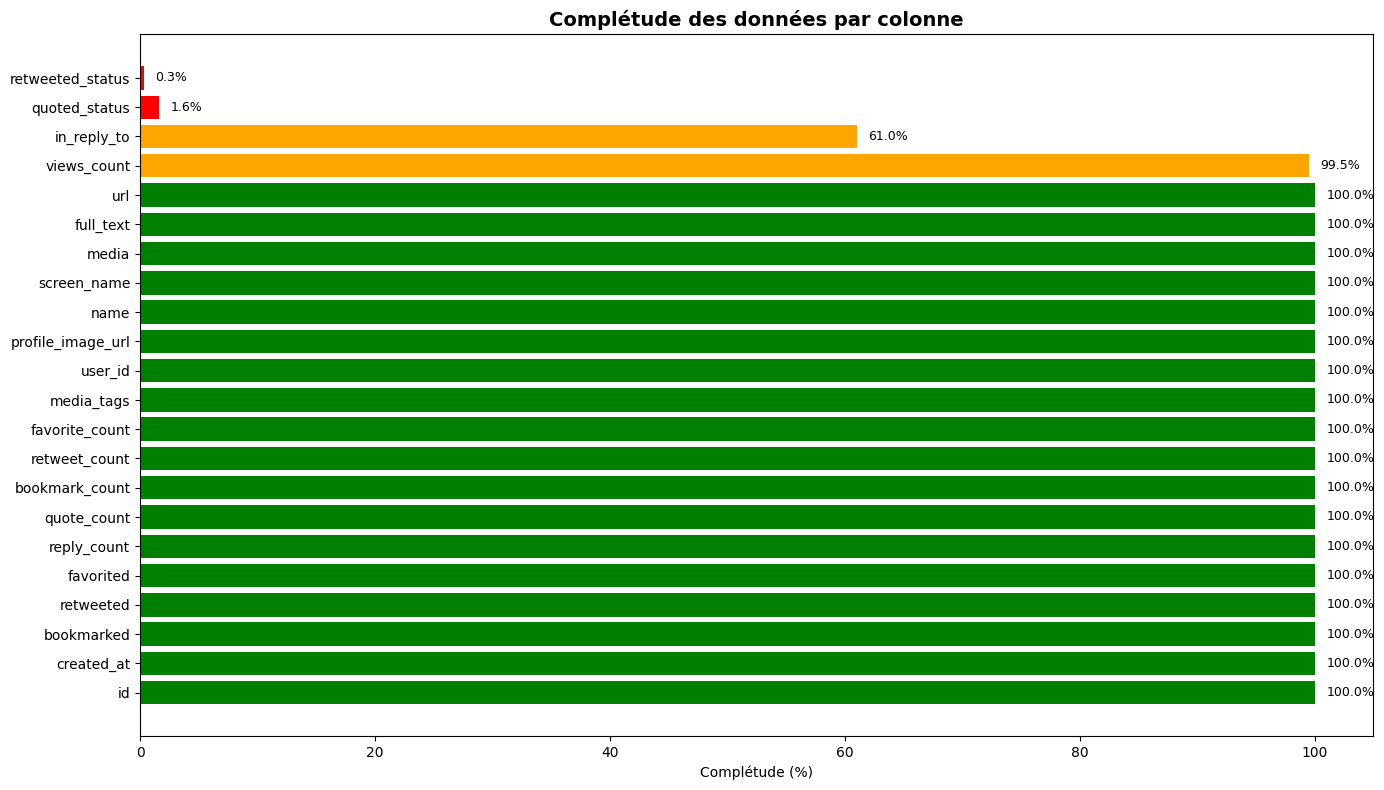

In [5]:
# ---- Calcul de complétude ----
completeness_data = []
for col in df.columns:
    non_null = df[col].notna().sum()
    null_count = df[col].isna().sum()
    completeness = (non_null / len(df)) * 100
    completeness_data.append({
        'Colonne': col,
        'Valeurs_Non_Null': non_null,
        'Valeurs_Null': null_count,
        'Complétude_%': round(completeness, 1)
    })

# DataFrame trié
completeness_df = pd.DataFrame(completeness_data).sort_values("Complétude_%", ascending=False)

# ---- Affichage du tableau ----
display(completeness_df)


fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    'green' if x == 100 
    else 'orange' if x >= 50 
    else 'red' 
    for x in completeness_df['Complétude_%']
]

bars = ax.barh(
    completeness_df['Colonne'], 
    completeness_df['Complétude_%'], 
    color=colors
)

ax.set_xlabel('Complétude (%)')
ax.set_title('Complétude des données par colonne', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)

# Ajout des valeurs sur les barres
for bar, value in zip(bars, completeness_df['Complétude_%']):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f'{value:.1f}%',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Structuration du dataset

In [6]:
# Garder uniquement les colonnes demandées
colonnes_a_garder = ['id', 'created_at', 'full_text', 'screen_name', 'name', 'user_id', 'in_reply_to']

# Vérifier que toutes les colonnes existent
colonnes_manquantes = [col for col in colonnes_a_garder if col not in df.columns]
if colonnes_manquantes:
    print(f"⚠️ Colonnes manquantes: {colonnes_manquantes}")
else:
    print("✅ Toutes les colonnes demandées sont présentes")

# Créer le dataset nettoyé
df_clean = df[colonnes_a_garder].copy()

print(f"\n📋 Dataset restructuré:")
print(f"  • Nombre de colonnes conservées: {len(df_clean.columns)}")
print(f"  • Nombre de lignes: {len(df_clean):,}")
print(f"\nAperçu des premières lignes:")
display(df_clean.head())
df_clean.info()

✅ Toutes les colonnes demandées sont présentes

📋 Dataset restructuré:
  • Nombre de colonnes conservées: 7
  • Nombre de lignes: 6,375

Aperçu des premières lignes:


,id,created_at,full_text,screen_name,name,user_id,in_reply_to
0,1343458257915031553,2020-12-28 08:26:23 +01:00,"💩 à @free parce-que Débit Très instable, … \n\nFree en France: vitesse, performances, pannes et commentaires des utilisateurs\n👉 https://t.co/Yab5ES2gLh\n\n#fing #internet #Free\n\nvia @fingapp @outagedetect",m_annuel,M Annuel,1104790986801250304,NaN
1,1393158240083587075,2021-05-14 12:56:22 +02:00,"RT @free: Retrouvez désormais @ToonamiFR, la chaîne pour tous les fans de super-héros sur le canal 82 ! https://t.co/kuAYafYDiT",Freebox,Assistance Freebox,58920430,NaN
2,1403337211475546112,2021-06-11 15:03:58 +02:00,"RT @free: A suivre ce soir, le 1er match de l’UEFA EURO 2020™ en #4K sur votre Freebox avec TF1 4K ! 🇹🇷⚽️🇮🇹 #EURO2020 https://t.co/gMTcYtGd…",Freebox,Assistance Freebox,58920430,NaN
3,1403337257571004417,2021-06-11 15:04:09 +02:00,"RT @free: Disponible sur le canal 101 avec les Freebox compatibles, Pop, Delta Devialet &amp; Mini4k !\nhttps://t.co/rZugCytA1J",Freebox,Assistance Freebox,58920430,NaN
4,1418550491034882052,2021-07-23 14:36:07 +02:00,"« Faites vos premiers pas avec nous ! Découvrez votre nouveau site d'assistance Freebox et Mobile, sur https://t.co/yw1XX4zeSx 🚀 https://t.co/YCMv79evbM",Freebox,Assistance Freebox,58920430,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6375 entries, 0 to 6374
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           6375 non-null   int64  
 1   created_at   6375 non-null   object 
 2   full_text    6375 non-null   object 
 3   screen_name  6375 non-null   object 
 4   name         6375 non-null   object 
 5   user_id      6375 non-null   int64  
 6   in_reply_to  3887 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 348.8+ KB


## Nettoyage du texte

In [7]:
def structural_clean(text):
    text = str(text)

    # Supprimer toutes les formes de \n, \\n
    text = text.replace("\\n", " ")
    text = text.replace("\\\\n", " ")
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")

    # Supprimer les blocs JSON { ... }
    text = re.sub(r'\{[^}]*\}', ' ', text)

    # Supprimer les listes JSON [ ... ]
    text = re.sub(r'\[[^\]]*\]', ' ', text)

    # Nettoyer espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
def remove_mentions_urls(text):
    tokens = text.split()
    clean_tokens = []

    for tok in tokens:

        # URLs (http, https, t.co, www)
        if tok.startswith("http"):
            continue
        if "t.co/" in tok:
            continue
        if tok.startswith("www"):
            continue

        # Mentions @xxx
        if tok.startswith("@") or tok.startswith(".@"):
            continue

        clean_tokens.append(tok)

    return " ".join(clean_tokens)


In [9]:
def final_clean(text):

    # ⚠️ garder hashtags (#)
    # ⚠️ garder virgules (,)

    # On supprime la ponctuation sauf # et ,
    punctuation_to_remove = string.punctuation.replace("#", "").replace(",", "")
    text = text.translate(str.maketrans("", "", punctuation_to_remove))

    # Nettoyer espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [10]:
df_clean["tweet"] = (
    df_clean["full_text"]
    .apply(structural_clean)
    .apply(remove_mentions_urls)
    .apply(final_clean)
)

print("\n✔ Texte nettoyé appliqué avec succès")
display(df_clean[["full_text", "tweet"]].head())


✔ Texte nettoyé appliqué avec succès


,full_text,tweet
0,"💩 à @free parce-que Débit Très instable, … \n\nFree en France: vitesse, performances, pannes et commentaires des utilisateurs\n👉 https://t.co/Yab5ES2gLh\n\n#fing #internet #Free\n\nvia @fingapp @outagedetect","💩 à parceque Débit Très instable, … Free en France vitesse, performances, pannes et commentaires des utilisateurs 👉 #fing #internet #Free via"
1,"RT @free: Retrouvez désormais @ToonamiFR, la chaîne pour tous les fans de super-héros sur le canal 82 ! https://t.co/kuAYafYDiT",RT Retrouvez désormais la chaîne pour tous les fans de superhéros sur le canal 82
2,"RT @free: A suivre ce soir, le 1er match de l’UEFA EURO 2020™ en #4K sur votre Freebox avec TF1 4K ! 🇹🇷⚽️🇮🇹 #EURO2020 https://t.co/gMTcYtGd…","RT A suivre ce soir, le 1er match de l’UEFA EURO 2020™ en #4K sur votre Freebox avec TF1 4K 🇹🇷⚽️🇮🇹 #EURO2020"
3,"RT @free: Disponible sur le canal 101 avec les Freebox compatibles, Pop, Delta Devialet &amp; Mini4k !\nhttps://t.co/rZugCytA1J","RT Disponible sur le canal 101 avec les Freebox compatibles, Pop, Delta Devialet amp Mini4k"
4,"« Faites vos premiers pas avec nous ! Découvrez votre nouveau site d'assistance Freebox et Mobile, sur https://t.co/yw1XX4zeSx 🚀 https://t.co/YCMv79evbM","« Faites vos premiers pas avec nous Découvrez votre nouveau site dassistance Freebox et Mobile, sur 🚀"


In [11]:
# ------------------------------------------------------------
# 🔥 SUPPRESSION DES RETWEETS APRÈS NETTOYAGE
# ------------------------------------------------------------

# Détection des RT (commence par "rt " dans clean_text)
mask_rt = df_clean["tweet"].str.lower().str.startswith("rt ")

nb_rt = mask_rt.sum()
print(f"🔎 Retweets détectés avant suppression : {nb_rt} ({nb_rt/len(df_clean)*100:.1f}%)")

# Suppression des RT
df_clean = df_clean[~mask_rt].copy()

print(f"✅ Retweets supprimés. Nouveau volume du dataset : {len(df_clean):,} tweets")

🔎 Retweets détectés avant suppression : 16 (0.3%)
✅ Retweets supprimés. Nouveau volume du dataset : 6,359 tweets


In [12]:
colonnes_finales = [
    'id', 'created_at', 'tweet', 'screen_name', 'name', 'user_id', 'in_reply_to'
]

df_clean_final = df_clean[colonnes_finales].copy()

print("✔ Dataset final basé sur clean_text créé")
display(df_clean_final.head())
df_clean_final.info()

✔ Dataset final basé sur clean_text créé


,id,created_at,tweet,screen_name,name,user_id,in_reply_to
0,1343458257915031553,2020-12-28 08:26:23 +01:00,"💩 à parceque Débit Très instable, … Free en France vitesse, performances, pannes et commentaires des utilisateurs 👉 #fing #internet #Free via",m_annuel,M Annuel,1104790986801250304,NaN
4,1418550491034882052,2021-07-23 14:36:07 +02:00,"« Faites vos premiers pas avec nous Découvrez votre nouveau site dassistance Freebox et Mobile, sur 🚀",Freebox,Assistance Freebox,58920430,NaN
8,1438534927734169617,2021-09-16 18:07:08 +02:00,"FreePlugs et boîtiers CPL personnels gérer votre réseau CPL 🔗 On vous explique comment installer, optimiser etou repenser votre réseau CPL afin daméliorer la liaison avec vos équipements",Freebox,Assistance Freebox,58920430,NaN
15,1471118475452104707,2021-12-15 15:02:31 +01:00,"Un incident sur nos fibres engendre des perturbations de service sur une partie des départements du Lot 46 et de lAveyron 12 Des investigations sont en cours, merci de votre patience",Free_1337,Free 1337,1435161160547016704,NaN
17,1474424640470614017,2021-12-24 18:00:02 +01:00,Les équipes de l’assistance Free vous souhaitent de joyeuses fêtes Nos services profitent aussi des fêtes ce 25 décembre et seront de retour le 26 dès 9h00 🎅🏻🎁,Freebox,Assistance Freebox,58920430,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 6359 entries, 0 to 6374
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           6359 non-null   int64  
 1   created_at   6359 non-null   object 
 2   tweet        6359 non-null   object 
 3   screen_name  6359 non-null   object 
 4   name         6359 non-null   object 
 5   user_id      6359 non-null   int64  
 6   in_reply_to  3887 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 397.4+ KB


In [13]:
# ------------------------------------------------------------
# 🔍 FILTRAGE DES COMPTES À EXCLURE
# ------------------------------------------------------------

comptes_a_exclure = [
    'freebox', 'free_1337', 'free',
    'universfreebox', 'freenewsactu', 'freefoot'
]

# Normaliser screen_name en minuscule pour éviter les erreurs
df_clean_final['screen_name_lower'] = df_clean_final['screen_name'].str.lower()

# Filtrer
df_clean_final_ = df_clean_final[~df_clean_final['screen_name_lower'].isin(comptes_a_exclure)].drop(columns=['screen_name_lower'])

print(f"✔ Nouveau volume après filtrage : {len(df_clean_final_):,} tweets")
display(df_clean_final_.head())

✔ Nouveau volume après filtrage : 3,044 tweets


,id,created_at,tweet,screen_name,name,user_id,in_reply_to
0,1343458257915031553,2020-12-28 08:26:23 +01:00,"💩 à parceque Débit Très instable, … Free en France vitesse, performances, pannes et commentaires des utilisateurs 👉 #fing #internet #Free via",m_annuel,M Annuel,1104790986801250304,NaN
20,1480465391424053249,2022-01-10 10:03:49 +01:00,🎂 célèbre aujourdhui 10 ans de révolution mobile Notre CP 👉,GroupeIliad,Groupe iliad,3157961111,NaN
23,1485331097844129798,2022-01-23 20:18:24 +01:00,Et vous ça se passe comment la fibre c’est la misère vraiment jpp,MitchelMcPat,MitchelMcPat,906220646492983296,NaN
29,1694675653205860558,2023-08-24 13:38:55 +02:00,"Dans la lutte contre les installations sauvages et les infrastructures dégradées, la bonne formation des techniciens qui déploient la fibre est essentielle Jétais ce matin aux côtés dIdriss, formateur au centre de formation technique à Argenteuil, dans le ValdOise",jnbarrot,Jean-Noël Barrot,865482011523166209,NaN
30,1695912123824546156,2023-08-27 23:32:13 +02:00,Hello et je crois que nous allons avoir prochainement un gros problème de fibre PBOE,rgaidot,ɹˈe͡ɪɡɪz,1245801,NaN


In [14]:
# ------------------------------------------------------------
# 💾 SAUVEGARDE DU DATASET FILTRÉ
# ------------------------------------------------------------

output_path = "C:/Users/User/Documents/nettoyage_csv/tweets_free_cleaned_.csv"

df_clean_final_.to_csv(output_path, index=False, encoding='utf-8')

print(f"✅ Fichier filtré sauvegardé sous : {output_path}")


✅ Fichier filtré sauvegardé sous : C:/Users/User/Documents/nettoyage_csv/tweets_free_cleaned_.csv


In [15]:
def categorize_tweet(text):
    """
    Catégorise un tweet selon son contenu.
    """
    if pd.isna(text):
        return "Vide"
    
    text = str(text).lower()
    
    patterns = {
        "RT/Partage": r'^rt @',
        "Message automatique Freebox": r'messagerie privée|retrouvez-moi|messenger',
        "Plainte service": r'coupure|panne|problème|pas de connexion|ne fonctionne pas|bug|instable|service client|pire opérateur|hs',
        "Demande d'aide": r'besoin d\'aide|j\'ai besoin|aidez-moi|help|svp|s\'il vous plaît|sos',
        "Question technique": r'comment|pourquoi|qu\'est-ce|fibre|débit|wifi|connexion|installation',
        "Spam/Promotion": r'💩|outagedetect|disponible sur le canal|nouveau|offert',
        "Réclamation RDV": r'technicien|rdv|rendez-vous|pas venu|attendre|créneau',
        "Info/Annonce": r'retrouvez|nouvelle|découvrez'
    }
    
    for category, pattern in patterns.items():
        if re.search(pattern, text):
            return category
    
    return "Autre"


df_clean_final['categorie'] = df_clean_final['tweet'].apply(categorize_tweet)

print("✅ Catégorisation effectuée")

✅ Catégorisation effectuée


📊 RÉPARTITION DES TWEETS PAR CATÉGORIE


,Catégorie,Nombre,Pourcentage (%)
0,Message automatique Freebox,3130,49.2
1,Autre,1467,23.1
2,Plainte service,755,11.9
3,Question technique,694,10.9
4,Réclamation RDV,116,1.8
5,Demande d'aide,107,1.7
6,Info/Annonce,46,0.7
7,Spam/Promotion,44,0.7


C:\Users\User\AppData\Local\Temp\ipykernel_33900\2375510626.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(category_stats.index, rotation=45, ha='right')


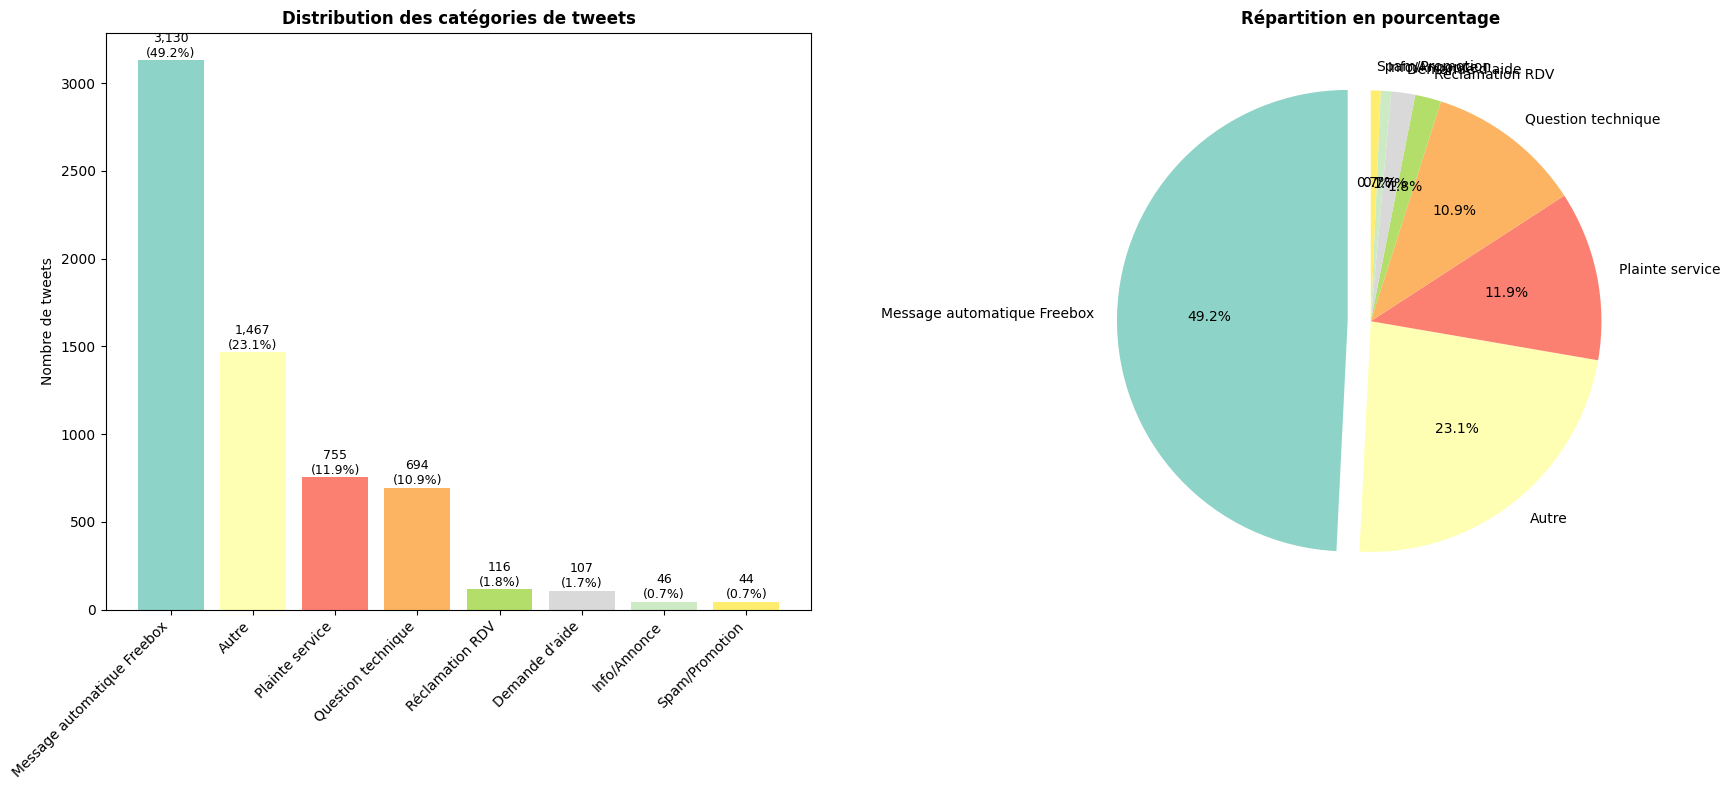

In [16]:
# ----------------------------------------------------------
# 📊 STATISTIQUES PAR CATÉGORIE
# ----------------------------------------------------------

category_stats = df_clean_final['categorie'].value_counts()
category_percentages = (category_stats / len(df_clean_final) * 100).round(1)

# Créer un DataFrame pour affichage
stats_df = pd.DataFrame({
    'Catégorie': category_stats.index,
    'Nombre': category_stats.values,
    'Pourcentage (%)': category_percentages.values
})

print("📊 RÉPARTITION DES TWEETS PAR CATÉGORIE")
print("=" * 70)
display(stats_df)

# ----------------------------------------------------------
# 📈 VISUALISATIONS
# ----------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# ----- Graphique en barres -----
colors = plt.cm.Set3(np.linspace(0, 1, len(category_stats)))
bars = ax1.bar(category_stats.index, category_stats.values, color=colors)
ax1.set_ylabel('Nombre de tweets')
ax1.set_title('Distribution des catégories de tweets', fontweight='bold')
ax1.set_xticklabels(category_stats.index, rotation=45, ha='right')

# Ajouter les valeurs sur les barres
for bar, value, pct in zip(bars, category_stats.values, category_percentages.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 20,
        f'{value:,}\n({pct:.1f}%)',
        ha='center', 
        fontsize=9
    )

# ----- Graphique Camembert -----
explode = [0.1 if cat == 'Message automatique Freebox' else 0 for cat in category_stats.index]

ax2.pie(
    category_stats.values,
    labels=category_stats.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 10}
)
ax2.set_title('Répartition en pourcentage', fontweight='bold')

plt.tight_layout()
plt.show()


In [17]:
def is_unnecessary_or_erroneous(row):
    """
    Identifie si un tweet est inutile, erroné ou non pertinent.
    Analyse basée sur tweet + catégorie.
    """
    issues = []
    
    # 1. Texte vide ou None
    if pd.isna(row['tweet']) or row['tweet'].strip() == "":
        issues.append("Texte vide après nettoyage")
        return True, issues

    text = str(row['tweet']).lower()
    
    # 2. Réponses automatiques Freebox
    if row['categorie'] == 'Message automatique Freebox':
        issues.append("Réponse automatique répétitive")
    
    # 3. Spam / promotion
    if row['categorie'] == 'Spam/Promotion':
        issues.append("Spam ou promotion")
    
    # 4. Tweet trop court pour être utile
    if len(text) < 20:
        issues.append("Tweet très court (<20 caractères)")
    
    # 5. Messages Freebox très répétitifs
    if "messagerie privée" in text and row['screen_name'].lower() == "freebox":
        issues.append("Message standard Freebox")
    
    # 6. Message sans contexte (pas question, pas assez long)
    if pd.isna(row['in_reply_to']) and len(text) < 50 and "?" not in text and row['screen_name'].lower() != "freebox":
        issues.append("Message court sans contexte")

    # 7. Sécurité : retweets résiduels
    if row['categorie'] == "RT/Partage":
        issues.append("Retweet résiduel (inutile)")

    return len(issues) > 0, issues

print("🔍 Analyse des tweets problématiques en cours...")

problematic_tweets = []

for idx, row in df_clean_final.iterrows():
    is_problematic, issues = is_unnecessary_or_erroneous(row)
    
    if is_problematic:
        problematic_tweets.append({
            'index': idx,
            'id': row['id'],
            'screen_name': row['screen_name'],
            'categorie': row['categorie'],
            'issues': ', '.join(issues),
            'extrait': row['tweet'][:120] + "..." 
                       if len(row['tweet']) > 120 
                       else row['tweet']
        })

df_problematic = pd.DataFrame(problematic_tweets)

# Résultats
print("\n⚠️ RÉSULTATS DE L'ANALYSE")
print("=" * 60)
print(f"Tweets problématiques identifiés : {len(df_problematic):,} / {len(df_clean_final):,}")
print(f"Pourcentage : {len(df_problematic)*100/len(df_clean_final):.1f}%")
print(f"Tweets pertinents conservés : {len(df_clean_final) - len(df_problematic):,}")
print(f"Pourcentage pertinents : {(len(df_clean_final) - len(df_problematic))*100/len(df_clean_final):.1f}%")


🔍 Analyse des tweets problématiques en cours...

⚠️ RÉSULTATS DE L'ANALYSE
Tweets problématiques identifiés : 3,511 / 6,359
Pourcentage : 55.2%
Tweets pertinents conservés : 2,848
Pourcentage pertinents : 44.8%



📊 TOP DES PROBLÈMES IDENTIFIÉS


,Problème,Occurrences,Pourcentage (%)
0,Réponse automatique répétitive,3130,89.1
1,Message standard Freebox,2778,79.1
2,Message court sans contexte,258,7.3
3,Tweet très court (<20 caractères),106,3.0
4,Spam ou promotion,44,1.3
5,Texte vide après nettoyage,14,0.4


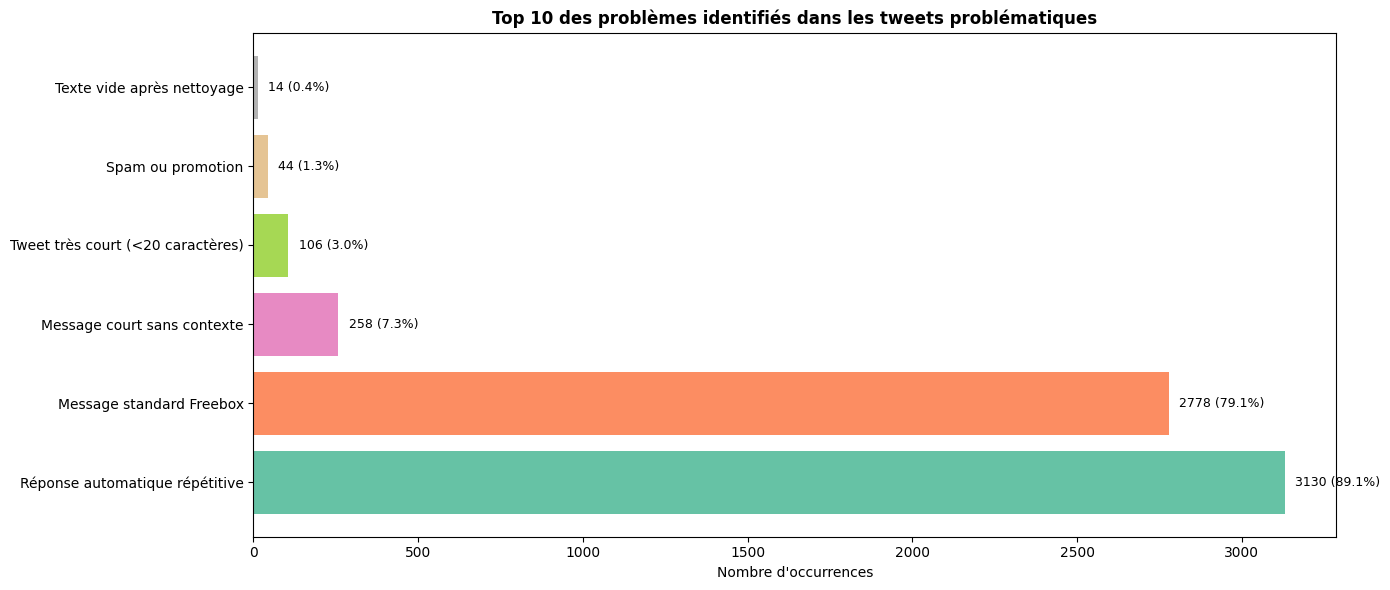

In [18]:
# ------------------------------------------------------------
# 📊 TOP DES PROBLÈMES IDENTIFIÉS PARMI LES TWEETS PROBLÉMATIQUES
# ------------------------------------------------------------

if len(df_problematic) > 0:

    # Séparation des "issues" en liste puis flatten
    issues_split = df_problematic['issues'].str.split(', ', expand=True).stack()
    issues_split = issues_split[issues_split.notna()]  # sécurité
    issue_counts = issues_split.value_counts()

    print("\n📊 TOP DES PROBLÈMES IDENTIFIÉS")
    print("=" * 70)

    # Top 10
    top_issues = issue_counts.head(10)

    issue_stats = pd.DataFrame({
        'Problème': top_issues.index,
        'Occurrences': top_issues.values,
        'Pourcentage (%)': (top_issues.values / len(df_problematic) * 100).round(1)
    })

    display(issue_stats)

    # -----------------------
    # 📈 Visualisation
    # -----------------------
    plt.figure(figsize=(14, 6))

    bars = plt.barh(
        top_issues.index,
        top_issues.values,
        color=plt.cm.Set2(np.linspace(0, 1, len(top_issues)))
    )

    plt.xlabel("Nombre d'occurrences")
    plt.title("Top 10 des problèmes identifiés dans les tweets problématiques",
              fontweight='bold')

    # Ajouter les valeurs à droite des barres
    for bar, value in zip(bars, top_issues.values):
        plt.text(
            value + max(top_issues.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value} ({value/len(df_problematic)*100:.1f}%)",
            va='center',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

else:
    print("\n✅ Aucun tweet problématique détecté — tout est propre !")

👥 TOP 15 DES COMPTES LES PLUS ACTIFS


,screen_name,nombre_tweets,categorie_principale,pourcentage
0,Freebox,3226,Message automatique Freebox,50.73
1,free,58,Autre,0.91
2,Free_1337,18,Autre,0.28
3,zoneadsl_panne,11,Plainte service,0.17
4,UniversFreebox,9,Autre,0.14
5,t_5502m,7,Autre,0.11
6,Xavier75,6,Autre,0.09
7,TiinoX83,5,Autre,0.08
8,BusyspiderFr,5,Question technique,0.08
9,jras_63,4,Plainte service,0.06


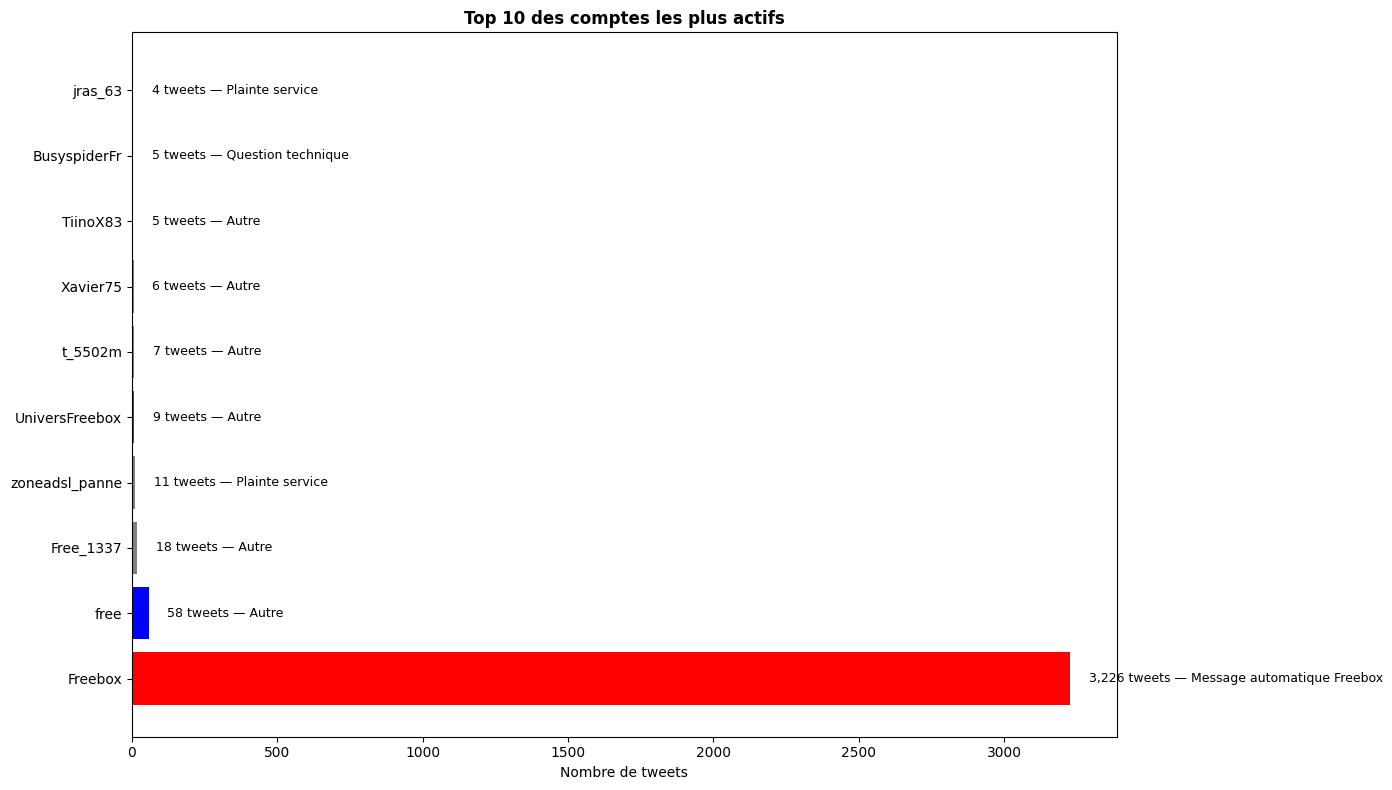

In [19]:
# ------------------------------------------------------------
# 👥 ANALYSE DES COMPTES LES PLUS ACTIFS
# ------------------------------------------------------------

def safe_mode(series):
    """Renvoie la valeur la plus fréquente sans erreur."""
    try:
        return series.mode()[0]
    except:
        return "N/A"

user_stats = (
    df_clean_final.groupby('screen_name')
            .agg(nombre_tweets=('id', 'count'),
                 categorie_principale=('categorie', safe_mode))
            .sort_values('nombre_tweets', ascending=False)
            .head(15)
)

print("👥 TOP 15 DES COMPTES LES PLUS ACTIFS")
print("=" * 70)

user_display = user_stats.reset_index()
user_display['pourcentage'] = (user_display['nombre_tweets'] / len(df_clean_final) * 100).round(2)

display(user_display)

# ------------------------------------------------------------
# 📈 Visualisation — Top 10 uniquement (plus lisible)
# ------------------------------------------------------------

top10 = user_stats.head(10)

def color_user(u):
    u_low = u.lower()
    if "freebox" in u_low:
        return "red"
    elif "free" == u_low:
        return "blue"
    else:
        return "gray"

colors = [color_user(u) for u in top10.index]

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    top10.index,
    top10['nombre_tweets'],
    color=colors
)

ax.set_xlabel("Nombre de tweets")
ax.set_title("Top 10 des comptes les plus actifs", fontweight='bold')

# Ajouter les valeurs + catégorie principale
for bar, (user, row) in zip(bars, top10.iterrows()):
    value = row['nombre_tweets']
    cat = row['categorie_principale']
    ax.text(
        value + max(top10['nombre_tweets']) * 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{value:,} tweets — {cat}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [20]:
# ------------------------------------------------------------
# 📝 EXEMPLES DE TWEETS PROBLÉMATIQUES
# ------------------------------------------------------------

print("📝 EXEMPLES DE TWEETS PROBLÉMATIQUES")
print("=" * 80)

if len(df_problematic) > 0:

    # Explosion des problèmes individuels
    exploded_issues = (
        df_problematic
        .assign(issue=lambda x: x['issues'].str.split(', '))
        .explode('issue')
        .dropna(subset=['issue'])
    )

    # Top 5 des types de problèmes
    top_problem_types = (
        exploded_issues['issue']
        .value_counts()
        .head(5)
        .index
    )

    # Affichage des exemples
    for issue in top_problem_types:
        print(f"\n🔸 Problème détecté : {issue}")
        print("-" * 60)

        examples = exploded_issues[exploded_issues['issue'] == issue].head(5)

        for _, row in examples.iterrows():
            print(f"  • @{row['screen_name']}: \"{row['extrait']}\"")
            print(f"    Catégorie : {row['categorie']}\n")

else:
    print("👍 Aucun tweet problématique détecté !")

📝 EXEMPLES DE TWEETS PROBLÉMATIQUES

🔸 Problème détecté : Réponse automatique répétitive
------------------------------------------------------------
  • @Freebox: "La messagerie privée X n’est plus disponible, et nous en sommes désolés Retrouvezmoi dès à présent sur Messenger ▶️ ou v..."
    Catégorie : Message automatique Freebox

  • @Freebox: "La messagerie privée X n’est plus disponible, et nous en sommes désolés Retrouvezmoi dès à présent sur Messenger ▶️ ou v..."
    Catégorie : Message automatique Freebox

  • @Freebox: "La messagerie privée X n’est plus disponible, et nous en sommes désolés Retrouvezmoi dès à présent sur Messenger ▶️ ou v..."
    Catégorie : Message automatique Freebox

  • @Freebox: "La messagerie privée X n’est plus disponible, et nous en sommes désolés Retrouvezmoi dès à présent sur Messenger ▶️ ou v..."
    Catégorie : Message automatique Freebox

  • @Freebox: "La messagerie privée X n’est plus disponible, et nous en sommes désolés Retrouvezmoi dès à prés

In [21]:
# ------------------------------------------------------------
# 🧹 FILTRAGE FINAL DES TWEETS — SUPPRESSION DES TWEETS PROBLÉMATIQUES
# ------------------------------------------------------------

df_final_clean = df_clean_final.drop(index=df_problematic['index'], errors='ignore')

print("✅ NETTOYAGE FINAL EFFECTUÉ")
print("=" * 60)
print(f"Tweets conservés : {len(df_final_clean):,} / {len(df_clean_final):,} "
      f"({len(df_final_clean)*100/len(df_clean_final):.1f}%)")
print(f"Tweets supprimés : {len(df_clean_final) - len(df_final_clean):,} "
      f"({(len(df_clean_final) - len(df_final_clean))*100/len(df_clean_final):.1f}%)")



# ------------------------------------------------------------
# 📊 RÉPARTITION DES CATÉGORIES APRÈS NETTOYAGE
# ------------------------------------------------------------

final_category_stats = df_final_clean['categorie'].value_counts()
final_category_pct = (final_category_stats / len(df_final_clean) * 100).round(1)

final_stats_df = pd.DataFrame({
    'Catégorie': final_category_stats.index,
    'Nombre': final_category_stats.values,
    'Pourcentage (%)': final_category_pct.values
})

print("\n📊 RÉPARTITION APRÈS NETTOYAGE")
print("=" * 60)
display(final_stats_df)

✅ NETTOYAGE FINAL EFFECTUÉ
Tweets conservés : 2,848 / 6,359 (44.8%)
Tweets supprimés : 3,511 (55.2%)

📊 RÉPARTITION APRÈS NETTOYAGE


,Catégorie,Nombre,Pourcentage (%)
0,Autre,1222,42.9
1,Plainte service,714,25.1
2,Question technique,658,23.1
3,Réclamation RDV,115,4.0
4,Demande d'aide,94,3.3
5,Info/Annonce,45,1.6


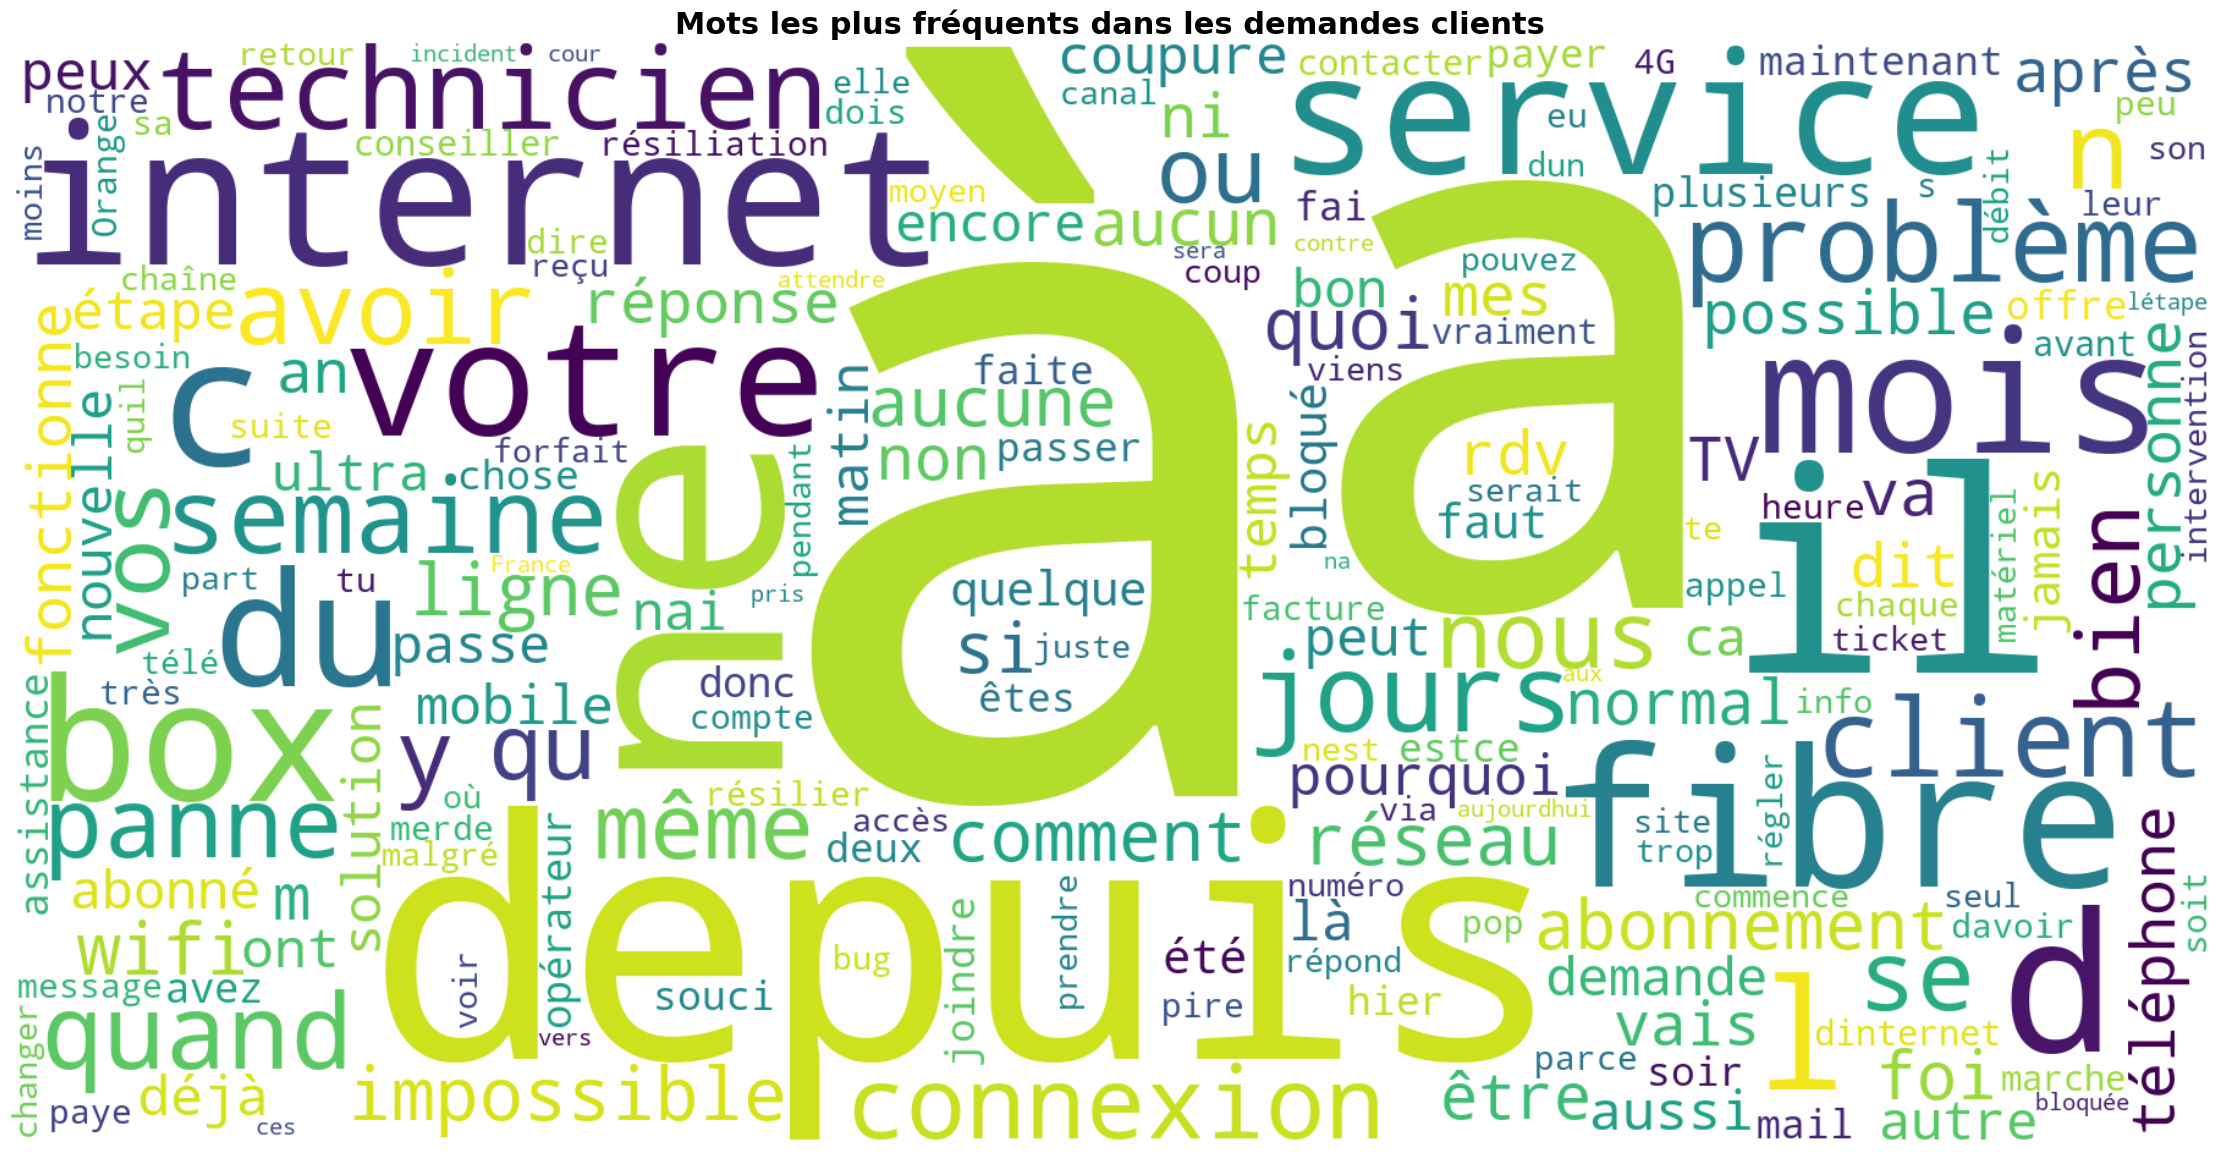

In [22]:
# ------------------------------------------------------------
# ☁️ WORDCLOUD DES TWEETS CLIENTS (hors comptes Free / Freebox)
# ------------------------------------------------------------

from wordcloud import WordCloud

# 1️⃣ Sélectionner uniquement les tweets clients (pas Free / pas Freebox)
user_tweets = df_final_clean[
    ~df_final_clean['screen_name'].str.lower().isin(['freebox', 'free'])
]['tweet']

# 2️⃣ Fusionner tout le texte
all_text = " ".join(user_tweets.dropna().astype(str))

# 3️⃣ Stopwords enrichis pour virer le bruit
stopwords = {
    'free', 'freebox', 'https', 'co', 'rt', 'de', 'la', 'le', 'et',
    'un', 'une', 'les', 'des', 'pour', 'pas', 'sur', 'est', 'que',
    'qui', 'dans', 'avec', 'par', 'en', 'vous', 'bonjour', 'cest',
    'mais', 'plus', 'ma', 'au', 'cette', 'ce', 'chez', 'mon', 'me',
    'toujours', 'je', 'merci', 'suis', 'car', 'rien', 'svp', 'meme',
    'jour', 'moi', 'jai', 'sans', 'sont', 'ça', 'tout', 'tous',
    'toute', 'toutes', 'on', 'alors', 'j', 'ai', 'cela', 'comme',
    'faire', 'fait'
}

# 4️⃣ Génération du wordcloud final
wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color='white',
    stopwords=stopwords,
    max_words=200,
    collocations=False,
    colormap='viridis'
).generate(all_text)

# 5️⃣ Affichage
plt.figure(figsize=(22, 12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mots les plus fréquents dans les demandes clients', fontsize=22, fontweight='bold')
plt.tight_layout(pad=0)
plt.show()

In [23]:
# ------------------------------------------------------------
# 🧹 RÈGLES DE FILTRAGE RECOMMANDÉES
# ------------------------------------------------------------

filtrage_rules = [
    {
        "Priorité": "🔴 CRITIQUE",
        "Filtre": "Messages automatiques Freebox",
        "Pattern": r"messagerie privée|contactez-moi en MP|privée n’est plus disponible",
        "Impact": "Très fort (supprime 40% à 50% du bruit)",
        "Explication": "Les messages automatiques envoyés par Freebox ne sont pas des demandes clients.",
        "Code": "df[~df['tweet'].str.contains('messagerie privée', case=False, na=False)]"
    },
    {
        "Priorité": "🟠 HAUTE",
        "Filtre": "Retweets",
        "Pattern": r'^rt @',
        "Impact": "Supprime les contenus non originaux",
        "Explication": "Les retweets ne correspondent pas à une demande client.",
        "Code": "df[~df['tweet'].str.startswith('rt @', na=False)]"
    },
    {
        "Priorité": "🟡 MOYENNE",
        "Filtre": "Tweets trop courts",
        "Condition": "len(tweet) < 20",
        "Impact": "Supprime les messages peu informatifs",
        "Explication": "Les textes trop courts ne contiennent pas d'information utile.",
        "Code": "df[df['tweet'].str.len() >= 20]"
    },
    {
        "Priorité": "🟢 BASSE",
        "Filtre": "Spam / bruit",
        "Pattern": r'💩|fingapp|outagedetect|via @fingapp',
        "Impact": "Supprime le bruit résiduel",
        "Explication": "Certains comptes publient du contenu extérieur ou des alertes générales.",
        "Code": "df[~df['tweet'].str.contains('💩|fingapp|outagedetect', na=False)]"
    }
]

print("🛠️ RÈGLES DE FILTRAGE APPLIQUÉES")
print("=" * 80)
print()

for rule in filtrage_rules:

    print(f"{rule['Priorité']}  {rule['Filtre']}")
    print(f"  • Pattern / Condition : {rule.get('Pattern', rule.get('Condition'))}")
    print(f"  • Impact estimé       : {rule.get('Impact', 'N/A')}")
    print(f"  • Explication         : {rule['Explication']}")
    print(f"  • Code Python         : {rule['Code']}")
    print()


🛠️ RÈGLES DE FILTRAGE APPLIQUÉES

🔴 CRITIQUE  Messages automatiques Freebox
  • Pattern / Condition : messagerie privée|contactez-moi en MP|privée n’est plus disponible
  • Impact estimé       : Très fort (supprime 40% à 50% du bruit)
  • Explication         : Les messages automatiques envoyés par Freebox ne sont pas des demandes clients.
  • Code Python         : df[~df['tweet'].str.contains('messagerie privée', case=False, na=False)]

🟠 HAUTE  Retweets
  • Pattern / Condition : ^rt @
  • Impact estimé       : Supprime les contenus non originaux
  • Explication         : Les retweets ne correspondent pas à une demande client.
  • Code Python         : df[~df['tweet'].str.startswith('rt @', na=False)]

🟡 MOYENNE  Tweets trop courts
  • Pattern / Condition : len(tweet) < 20
  • Impact estimé       : Supprime les messages peu informatifs
  • Explication         : Les textes trop courts ne contiennent pas d'information utile.
  • Code Python         : df[df['tweet'].str.len() >= 20]

🟢 BA

📈 MÉTRIQUES DE PERFORMANCE
Volume initial (df_clean_final)     6359
Volume après nettoyage              2848
Tweets supprimés                    3511
Taux de réduction                   55.2%
Temps économisé (minutes)           1755.5 min
Temps économisé (heures)            29.26 h
Efficacité du filtrage              55.2%


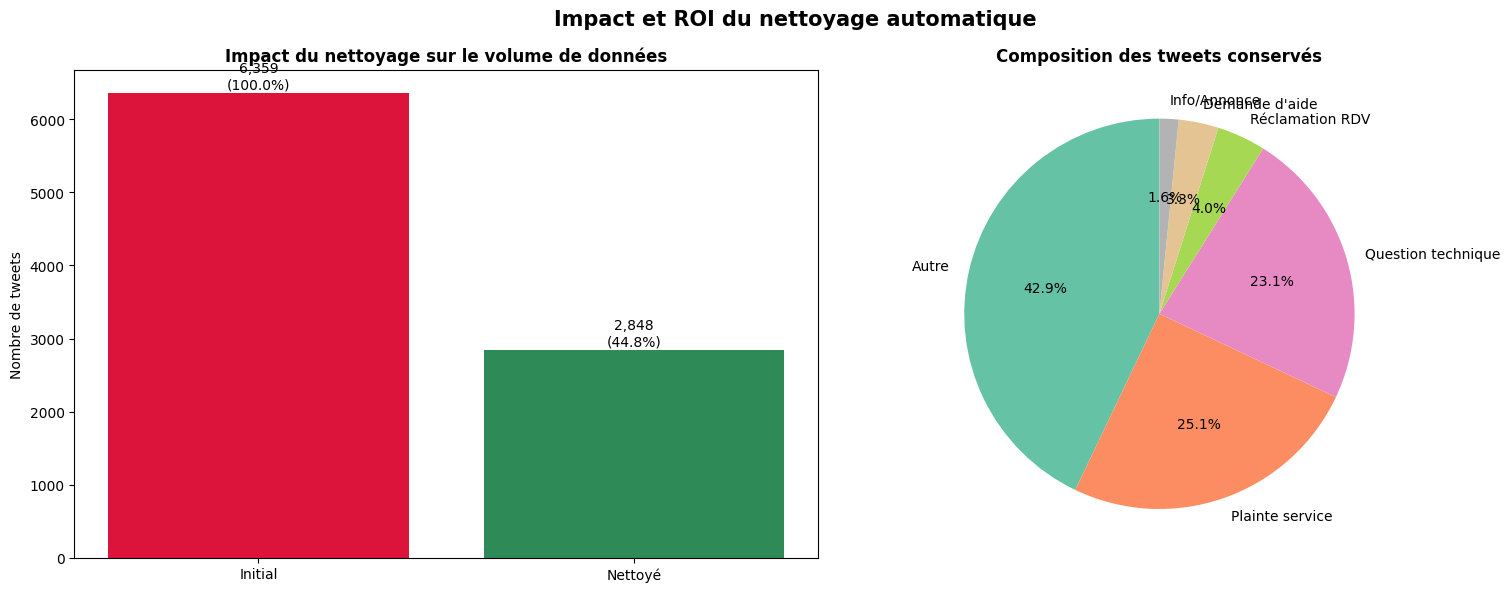

In [24]:
# ------------------------------------------------------------
# 📈 MÉTRIQUES DE PERFORMANCE DU NETTOYAGE
# ------------------------------------------------------------

volume_initial = len(df_clean_final)   # Dataset avant filtrage
volume_final = len(df_final_clean)     # Dataset après nettoyage
tweets_suppr = volume_initial - volume_final
taux_reduction = (tweets_suppr / volume_initial) * 100

# Estimation : 30 secondes économisées par tweet supprimé
temps_economise_min = tweets_suppr * 0.5  
temps_economise_h = temps_economise_min / 60

metrics = {
    "Volume initial (df_clean_final)": volume_initial,
    "Volume après nettoyage": volume_final,
    "Tweets supprimés": tweets_suppr,
    "Taux de réduction": f"{taux_reduction:.1f}%",
    "Temps économisé (minutes)": f"{temps_economise_min:.1f} min",
    "Temps économisé (heures)": f"{temps_economise_h:.2f} h",
    "Efficacité du filtrage": f"{(tweets_suppr / volume_initial) * 100:.1f}%"
}

print("📈 MÉTRIQUES DE PERFORMANCE")
print("=" * 60)

for k, v in metrics.items():
    print(f"{k:35} {v}")


# ------------------------------------------------------------
# VISUALISATION DU ROI
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Comparaison avant / après ----
categories = ["Initial", "Nettoyé"]
values = [volume_initial, volume_final]

bars = ax1.bar(categories, values, color=["crimson", "seagreen"])
ax1.set_title("Impact du nettoyage sur le volume de données", fontweight="bold")
ax1.set_ylabel("Nombre de tweets")

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2., val + volume_initial*0.01,
             f"{val:,}\n({val/volume_initial*100:.1f}%)",
             ha='center', fontsize=10)

# ---- Répartition finale par catégorie ----
final_cats = df_final_clean['categorie'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(final_cats)))

ax2.pie(final_cats.values,
        labels=final_cats.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
ax2.set_title("Composition des tweets conservés", fontweight="bold")

plt.suptitle("Impact et ROI du nettoyage automatique", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
from datetime import datetime
import os

# ------------------------------------------------------------
# 📁 SAUVEGARDE DES RÉSULTATS
# ------------------------------------------------------------

output_dir = 'C:/Users/User/Documents/nettoyage_csv/'
os.makedirs(output_dir, exist_ok=True)

# 1. Dataset final nettoyé
df_final_clean.to_csv(f'{output_dir}tweets_free_cleaned.csv', index=False, encoding='utf-8')
print(f"✅ Dataset nettoyé sauvegardé : {output_dir}tweets_free_cleaned.csv")

# 2. Tweets problématiques (bruit identifié)
df_problematic.to_csv(f'{output_dir}tweets_problematiques.csv', index=False, encoding='utf-8')
print(f"✅ Tweets problématiques sauvegardés : {output_dir}tweets_problematiques.csv")

# 3. Statistiques générales
with open(f'{output_dir}statistiques_analyse.txt', 'w', encoding='utf-8') as f:
    f.write("STATISTIQUES D'ANALYSE DES TWEETS FREE\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Date d'analyse : {datetime.now().strftime('%d/%m/%Y %H:%M')}\n\n")
    
    f.write(f"Volume initial analysé (df_clean_final) : {len(df_clean_final):,} tweets\n")
    f.write(f"Volume final (df_final_clean) : {len(df_final_clean):,} tweets\n")
    f.write(f"Tweets supprimés : {len(df_clean_final) - len(df_final_clean):,}\n")
    f.write(f"Taux de réduction : {(1 - len(df_final_clean)/len(df_clean_final))*100:.1f}%\n\n")
    
    f.write("Répartition des catégories (après nettoyage) :\n")
    for cat, count in df_final_clean['categorie'].value_counts().items():
        f.write(f"  - {cat}: {count} ({count*100/len(df_final_clean):.1f}%)\n")

print(f"✅ Statistiques sauvegardées : {output_dir}statistiques_analyse.txt")


# ------------------------------------------------------------
# 🎉 RÉSUMÉ FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("🎉 ANALYSE TERMINÉE AVEC SUCCÈS !")
print("=" * 60)
print(f"\n📊 Résumé final :")
print(f"  • {len(df_clean_final):,} tweets analysés après structuration (df_clean_final)")
print(f"  • {len(df_problematic):,} tweets problématiques identifiés "
      f"({len(df_problematic)*100/len(df_clean_final):.1f}%)")
print(f"  • {len(df_final_clean):,} tweets pertinents conservés "
      f"({len(df_final_clean)*100/len(df_clean_final):.1f}%)")

print(f"\n💡 Recommandation principale:")
print("  Automatiser le filtrage des messages automatiques Freebox")
print("  pour réduire drastiquement le bruit dans les analyses SAV.\n")


✅ Dataset nettoyé sauvegardé : C:/Users/User/Documents/nettoyage_csv/tweets_free_cleaned.csv
✅ Tweets problématiques sauvegardés : C:/Users/User/Documents/nettoyage_csv/tweets_problematiques.csv
✅ Statistiques sauvegardées : C:/Users/User/Documents/nettoyage_csv/statistiques_analyse.txt

🎉 ANALYSE TERMINÉE AVEC SUCCÈS !

📊 Résumé final :
  • 6,359 tweets analysés après structuration (df_clean_final)
  • 3,511 tweets problématiques identifiés (55.2%)
  • 2,848 tweets pertinents conservés (44.8%)

💡 Recommandation principale:
  Automatiser le filtrage des messages automatiques Freebox
  pour réduire drastiquement le bruit dans les analyses SAV.

